# ITCS 6169/8169 — Computer Vision
## Assignment 1: The CNN Challenge
**Due: September 25, 2026 at 11:59 PM EDT**

---

In this assignment, you will build and train a convolutional neural network (CNN) for **16-class scene recognition** using a small dataset of **2,400 training images**.

This notebook is intentionally only a **starter baseline**. It provides a clean training pipeline and a deliberately simple CNN. Your task is to improve the system through informed decisions about architecture, optimization, augmentation, regularization, model selection, and training strategy.

### 2026 workflow: AI is your pair programmer
Use of an AI coding assistant (e.g., ChatGPT, Codex, GitHub Copilot, Claude Code, Gemini, Cursor) is **required**. You may use AI to help implement, debug, refactor, explain, or suggest experiments. However, **you are responsible for the scientific decisions and for verifying all generated code**.

Your final GitHub repository must include an `AI_USAGE.md` file describing representative AI-assisted tasks, at least one incorrect/ineffective AI suggestion, how you verified or corrected it, and one important decision that you made yourself.

### Important model restriction
The primary classifier for Assignment 1 must be a **CNN**. Do **not** use CLIP, DINO/DINOv2, VLM APIs, Vision Transformers as the primary model, or other foundation-model embeddings for your main submission. Pretrained CNNs are allowed if clearly documented.

### Google Colab
Google Colab is recommended, but not required. If using Colab, enable a GPU through **Runtime → Change runtime type → GPU**. You may also use the Educational Cluster or another resource for which you have authorized access.

In [1]:
import torch

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

PyTorch version: 2.11.0+cu130
CUDA available: True
GPU: Tesla T4


In [2]:
# Core imports
from pathlib import Path
import random
import time
import copy

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

print(f"PyTorch version: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")

PyTorch version: 2.11.0+cu130
CUDA available: True


In [3]:
import os
import zipfile

# Uploaded dataset ZIP files
train_zip = "/content/train.zip"
test_zip = "/content/test.zip"

# Folders where the datasets will be extracted
train_extract_dir = "/content/train_data"
test_extract_dir = "/content/test_data"

# Create extraction folders
os.makedirs(train_extract_dir, exist_ok=True)
os.makedirs(test_extract_dir, exist_ok=True)

# Extract training dataset
with zipfile.ZipFile(train_zip, "r") as zip_ref:
    zip_ref.extractall(train_extract_dir)

# Extract test dataset
with zipfile.ZipFile(test_zip, "r") as zip_ref:
    zip_ref.extractall(test_extract_dir)

print("Train and test datasets extracted successfully.")

Train and test datasets extracted successfully.


In [4]:
print("Contents of train_data:")
print(os.listdir("/content/train_data"))

print("\nContents of test_data:")
print(os.listdir("/content/test_data"))

Contents of train_data:
['train']

Contents of test_data:
['test']


In [5]:
import os

TRAIN_ROOT = "/content/train_data/train"
TEST_ROOT = "/content/test_data/test"

print("Training folders:")
print(os.listdir(TRAIN_ROOT))

print("\nTest folders:")
print(os.listdir(TEST_ROOT))

print("\nNumber of training class folders:",
      len([f for f in os.listdir(TRAIN_ROOT)
           if os.path.isdir(os.path.join(TRAIN_ROOT, f))]))

print("Number of test class folders:",
      len([f for f in os.listdir(TEST_ROOT)
           if os.path.isdir(os.path.join(TEST_ROOT, f))]))

Training folders:
['Coast', 'Kitchen', '.DS_Store', 'Store', 'Forest', 'LivingRoom', 'Mountain', 'Flower', 'TallBuilding', 'InsideCity', 'Suburb', 'Bedroom', 'Street', 'Industrial', 'OpenCountry', 'Office', 'Highway']

Test folders:
['Coast', 'Kitchen', 'Store', 'Forest', 'LivingRoom', 'Mountain', 'Flower', 'TallBuilding', 'InsideCity', 'Suburb', 'Bedroom', 'Street', 'Industrial', 'OpenCountry', 'Office', 'Highway']

Number of training class folders: 16
Number of test class folders: 16


In [ ]:
# Optional: mount Google Drive when running in Colab.
# Skip this cell if you are running locally or on another server.
try:
    from google.colab import drive
    drive.mount('/content/gdrive')
except ImportError:
    print("Not running in Google Colab; Drive mount skipped.")

## 1. Set your working directory

Download the assignment dataset from the link provided in the assignment handout and organize it so that the notebook can find:

```text
data/
  train/
    class_1/
    ...
  test/
    class_1/
    ...
```

If you use Google Drive, change `PROJECT_ROOT` below to your assignment folder. **Do not hard-code a TA/instructor solution path.**

In [6]:
# CHANGE THIS PATH to your own assignment directory.
# Example for Colab + Google Drive:
# PROJECT_ROOT = Path('/content/gdrive/MyDrive/ITCS_6169_8169/assignment1')

PROJECT_ROOT = Path('/content')
# DATA_ROOT = PROJECT_ROOT / 'data' # I am uploading the datasets manually in colab.
TRAIN_ROOT = PROJECT_ROOT / 'train_data' / 'train'
TEST_ROOT = PROJECT_ROOT / 'test_data' / 'test'

print('Project root:', PROJECT_ROOT.resolve())
print('Training data:', TRAIN_ROOT)
print('Testing data:', TEST_ROOT)

Project root: /content
Training data: /content/train_data/train
Testing data: /content/test_data/test


## 2. Reproducibility and device

A fixed seed makes the starter result easier to reproduce. Exact GPU reproducibility is not always guaranteed across hardware/software versions, so report your environment and seed in the final repository.

In [7]:
SEED = 0

def set_random_seed(seed=SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Using device:', device)

Using device: cuda


## 3. Loading and preprocessing the data

The starter baseline converts images to grayscale and resizes them to $64\times64$. This is **not necessarily a good final choice**. You should decide whether color, resolution, normalization, and augmentation should be changed.

We split the provided training data into **training and validation sets**. Use the validation set for architecture/hyperparameter decisions. **Do not repeatedly tune on the test set.** The test set should be used for the final evaluation of a selected model.

In [8]:
IMG_SIZE = 64
BATCH_SIZE = 64
VAL_FRACTION = 0.20

# Deliberately simple preprocessing for the starter baseline.
# TODO: improve this as part of your experiments.
baseline_transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5], std=[0.5]),
])

full_train_dataset = datasets.ImageFolder(TRAIN_ROOT, transform=baseline_transform)
test_dataset = datasets.ImageFolder(TEST_ROOT, transform=baseline_transform)

class_names = full_train_dataset.classes
num_classes = len(class_names)
print(f'Classes ({num_classes}): {class_names}')
print(f'Total training images: {len(full_train_dataset)}')
print(f'Test images: {len(test_dataset)}')

val_size = int(round(len(full_train_dataset) * VAL_FRACTION))
train_size = len(full_train_dataset) - val_size
generator = torch.Generator().manual_seed(SEED)
train_dataset, val_dataset = random_split(
    full_train_dataset, [train_size, val_size], generator=generator
)

train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=2, pin_memory=torch.cuda.is_available())
val_loader = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False,
                        num_workers=2, pin_memory=torch.cuda.is_available())
test_loader = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=2, pin_memory=torch.cuda.is_available())

print(f'Train: {len(train_dataset)} | Validation: {len(val_dataset)} | Test: {len(test_dataset)}')

Classes (16): ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']
Total training images: 2400
Test images: 400
Train: 1920 | Validation: 480 | Test: 400


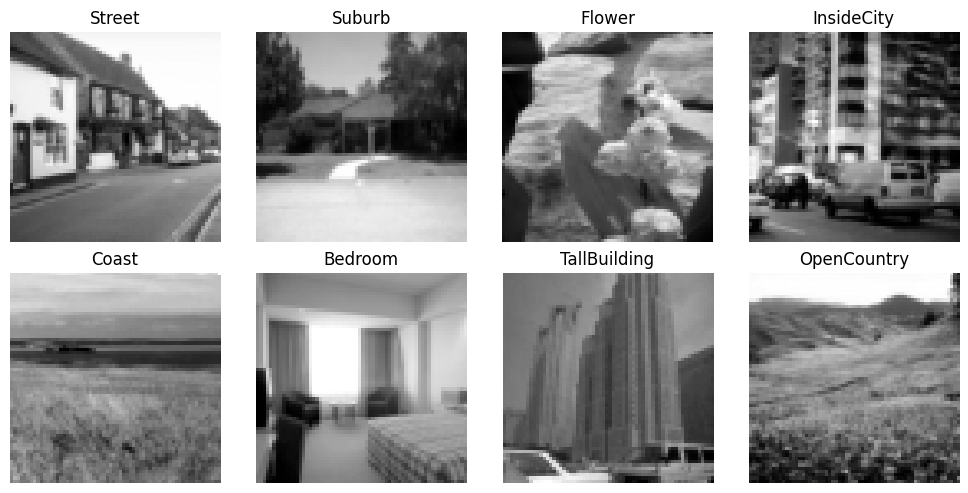

In [9]:
# Visualize a few training examples
images, labels = next(iter(train_loader))

fig, axes = plt.subplots(2, 4, figsize=(10, 5))
for ax, image, label in zip(axes.flat, images[:8], labels[:8]):
    image = image * 0.5 + 0.5  # unnormalize
    ax.imshow(image.squeeze(0), cmap='gray')
    ax.set_title(class_names[label.item()])
    ax.axis('off')
plt.tight_layout()
plt.show()

## 4. Training a CNN from scratch

Gone are the days when hand-designed features were the default solution. We will start with end-to-end learning and train a CNN directly for 16-way classification.

The architecture below is deliberately weak and simple. **Do not treat it as a recommended architecture.** It exists only to verify that the pipeline works and to give you a baseline to beat.

In [11]:
class TNet(nn.Module):
    """A deliberately small CNN starter baseline."""
    def __init__(self, num_classes=16):
        super().__init__()
        self.features = nn.Sequential(
            nn.Conv2d(1, 16, kernel_size=3),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(kernel_size=4, stride=4),
        )
        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(16 * 15 * 15, num_classes),
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)

model = TNet(num_classes=num_classes)
print(model)
print(f'Trainable parameters: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

TNet(
  (features): Sequential(
    (0): Conv2d(1, 16, kernel_size=(3, 3), stride=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=4, stride=4, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=3600, out_features=16, bias=True)
  )
)
Trainable parameters: 57,776


## 5. Training and evaluation utilities

The training loop below selects the checkpoint with the **best validation accuracy**. This is a much better experimental practice than evaluating the test set after every epoch.

You are welcome to rewrite this code. For example, you may add a scheduler, mixed precision, early stopping, checkpointing, experiment tracking, or richer metrics. If AI helps you implement such changes, verify the implementation and document representative usage in `AI_USAGE.md`.

In [10]:
@torch.inference_mode()
def evaluate(model, loader, device):
    model.eval()
    correct = 0
    total = 0
    running_loss = 0.0
    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:
        images = images.to(device, non_blocking=True)
        labels = labels.to(device, non_blocking=True)
        logits = model(images)
        loss = criterion(logits, labels)
        running_loss += loss.item() * images.size(0)
        correct += (logits.argmax(dim=1) == labels).sum().item()
        total += labels.size(0)

    return running_loss / total, correct / total


def train_model(model, train_loader, val_loader, optimizer, epochs=20, device=device):
    criterion = nn.CrossEntropyLoss()
    model = model.to(device)
    best_state = copy.deepcopy(model.state_dict())
    best_val_acc = 0.0
    history = {'train_loss': [], 'val_loss': [], 'val_acc': []}
    start = time.time()

    for epoch in range(1, epochs + 1):
        model.train()
        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)

            optimizer.zero_grad(set_to_none=True)
            logits = model(images)
            loss = criterion(logits, labels)
            loss.backward()
            optimizer.step()

            total_loss += loss.item() * images.size(0)
            total_seen += labels.size(0)

        train_loss = total_loss / total_seen
        val_loss, val_acc = evaluate(model, val_loader, device)
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_acc'].append(val_acc)

        if val_acc > best_val_acc:
            best_val_acc = val_acc
            best_state = copy.deepcopy(model.state_dict())

        elapsed = time.time() - start
        print(f'Epoch {epoch:02d}/{epochs} | '
              f'train loss {train_loss:.4f} | val loss {val_loss:.4f} | '
              f'val acc {val_acc:.4f} | {elapsed:.1f}s')

    model.load_state_dict(best_state)
    print(f'Best validation accuracy: {best_val_acc:.4f}')
    return model, history

In [12]:
# Train the deliberately simple baseline.
set_random_seed(SEED)
model = TNet(num_classes=num_classes)
optimizer = optim.Adam(model.parameters(), lr=0.002)

model, history = train_model(
    model, train_loader, val_loader, optimizer, epochs=20, device=device
)

NameError: name 'TNet' is not defined

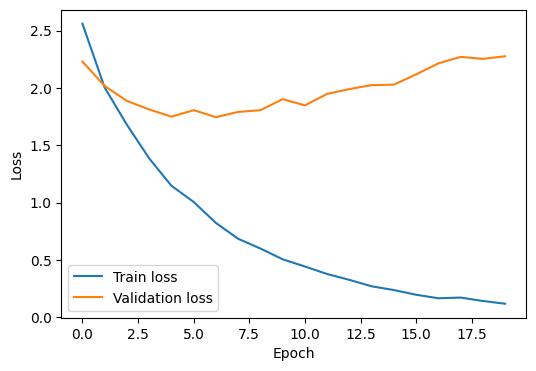

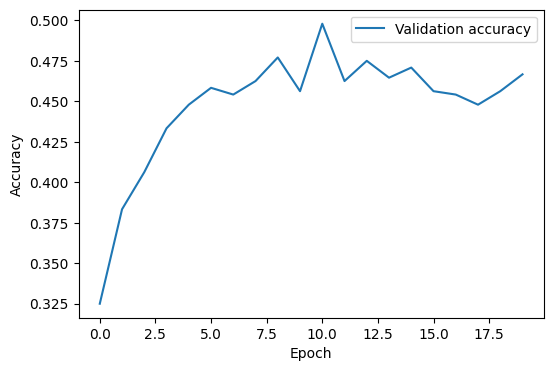

In [ ]:
# Plot the starter training history.
plt.figure(figsize=(6, 4))
plt.plot(history['train_loss'], label='Train loss')
plt.plot(history['val_loss'], label='Validation loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()

plt.figure(figsize=(6, 4))
plt.plot(history['val_acc'], label='Validation accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()

## 6. Your turn: beat the baseline

This simple model should only be treated as a sanity check. Your objective is to substantially improve it.

Rather than asking an AI tool to ``make the accuracy higher,'' formulate hypotheses yourself. Examples of useful questions include whether the model is overfitting, whether color matters, whether stronger augmentation helps, whether a different CNN family is more appropriate, whether pretrained CNN features transfer well, or whether optimization/regularization is limiting performance.

For each important experiment, write down:

| Experiment | What changed? | Why did you try it? | Validation accuracy | What did you learn? |
|---|---|---|---:|---|
| Baseline | Starter TNet | Sanity check | -- | -- |
| Experiment 1 | | | | |
| Experiment 2 | | | | |
| Final model | | | | |

**Do not use the test set to choose among these experiments.**

# Experiment 1: Improved CNN Architecture

### Improving the CNN architecture by adding three convolutional layers and dropout

In [ ]:
class ImprovedCNN(nn.Module):
    def __init__(self, num_classes=16):
        super().__init__()

        self.features = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(32, 64, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),

            nn.Conv2d(64, 128, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.MaxPool2d(2),
        )

        self.classifier = nn.Sequential(
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256),
            nn.ReLU(inplace=True),
            nn.Dropout(0.5),
            nn.Linear(256, num_classes)
        )

    def forward(self, x):
        x = self.features(x)
        return self.classifier(x)


model_exp1 = ImprovedCNN(num_classes=num_classes)

print(model_exp1)
print(
    f'Trainable parameters: '
    f'{sum(p.numel() for p in model_exp1.parameters() if p.requires_grad):,}'
)

ImprovedCNN(
  (features): Sequential(
    (0): Conv2d(1, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (1): ReLU(inplace=True)
    (2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (3): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (4): ReLU(inplace=True)
    (5): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (6): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
    (7): ReLU(inplace=True)
    (8): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  )
  (classifier): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=8192, out_features=256, bias=True)
    (2): ReLU(inplace=True)
    (3): Dropout(p=0.5, inplace=False)
    (4): Linear(in_features=256, out_features=16, bias=True)
  )
)
Trainable parameters: 2,194,192


In [ ]:
# Train Experiment 1: Improved CNN
set_random_seed(SEED)

model_exp1 = ImprovedCNN(num_classes=num_classes)

optimizer_exp1 = optim.Adam(
    model_exp1.parameters(),
    lr=0.002
)

model_exp1, history_exp1 = train_model(
    model_exp1,
    train_loader,
    val_loader,
    optimizer_exp1,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 2.7344 | val loss 2.5322 | val acc 0.2313 | 2.7s
Epoch 02/20 | train loss 2.4689 | val loss 2.2596 | val acc 0.3000 | 5.5s
Epoch 03/20 | train loss 2.1959 | val loss 2.0637 | val acc 0.3542 | 8.2s
Epoch 04/20 | train loss 1.9506 | val loss 1.9034 | val acc 0.4021 | 12.1s
Epoch 05/20 | train loss 1.7824 | val loss 1.8428 | val acc 0.3979 | 14.8s
Epoch 06/20 | train loss 1.5223 | val loss 1.6672 | val acc 0.4833 | 17.4s
Epoch 07/20 | train loss 1.3275 | val loss 1.6530 | val acc 0.4583 | 20.1s
Epoch 08/20 | train loss 1.1746 | val loss 1.6294 | val acc 0.5021 | 23.9s
Epoch 09/20 | train loss 1.0257 | val loss 1.6283 | val acc 0.4917 | 26.8s
Epoch 10/20 | train loss 0.8545 | val loss 1.8335 | val acc 0.4750 | 29.5s
Epoch 11/20 | train loss 0.7684 | val loss 1.9360 | val acc 0.4521 | 32.1s
Epoch 12/20 | train loss 0.6457 | val loss 1.8413 | val acc 0.4938 | 35.1s
Epoch 13/20 | train loss 0.5204 | val loss 1.8646 | val acc 0.5250 | 38.9s
Epoch 14/20 | train loss 0.4

# Experiment 2: ImageNet-1K Pretrained ResNet-18

### Using transfer learning with an ImageNet pretrained ResNet-18

In [18]:
from torchvision import models
from torch.utils.data import Subset

IMG_SIZE_EXP2 = 224

exp2_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_EXP2, IMG_SIZE_EXP2)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Experiment 2 transform created.")

Experiment 2 transform created.


In [19]:
train_base_exp2 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_transform
)

val_base_exp2 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_transform
)

train_dataset_exp2 = Subset(
    train_base_exp2,
    train_dataset.indices
)

val_dataset_exp2 = Subset(
    val_base_exp2,
    val_dataset.indices
)

train_loader_exp2 = DataLoader(
    train_dataset_exp2,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp2 = DataLoader(
    val_dataset_exp2,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(train_dataset_exp2))
print("Validation images:", len(val_dataset_exp2))

Training images: 1920
Validation images: 480


In [20]:
weights_exp2 = models.ResNet18_Weights.DEFAULT
model_exp2 = models.resnet18(weights=weights_exp2)

num_features = model_exp2.fc.in_features
model_exp2.fc = nn.Linear(num_features, num_classes)

print(model_exp2)
print(
    f'Trainable parameters: '
    f'{sum(p.numel() for p in model_exp2.parameters() if p.requires_grad):,}'
)

ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    )
    (1): BasicBlock(
      (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
  

In [21]:
set_random_seed(SEED)

optimizer_exp2 = optim.Adam(
    model_exp2.parameters(),
    lr=0.0001
)

model_exp2, history_exp2 = train_model(
    model_exp2,
    train_loader_exp2,
    val_loader_exp2,
    optimizer_exp2,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 1.2536 | val loss 0.4187 | val acc 0.8896 | 9.8s
Epoch 02/20 | train loss 0.2295 | val loss 0.2856 | val acc 0.9271 | 19.3s
Epoch 03/20 | train loss 0.0843 | val loss 0.2585 | val acc 0.9271 | 27.2s
Epoch 04/20 | train loss 0.0363 | val loss 0.2469 | val acc 0.9354 | 36.5s
Epoch 05/20 | train loss 0.0195 | val loss 0.2372 | val acc 0.9313 | 45.7s
Epoch 06/20 | train loss 0.0140 | val loss 0.2356 | val acc 0.9333 | 53.7s
Epoch 07/20 | train loss 0.0107 | val loss 0.2361 | val acc 0.9208 | 62.8s
Epoch 08/20 | train loss 0.0076 | val loss 0.2355 | val acc 0.9292 | 71.9s
Epoch 09/20 | train loss 0.0064 | val loss 0.2340 | val acc 0.9313 | 80.0s
Epoch 10/20 | train loss 0.0059 | val loss 0.2311 | val acc 0.9313 | 89.4s
Epoch 11/20 | train loss 0.0048 | val loss 0.2310 | val acc 0.9292 | 98.3s
Epoch 12/20 | train loss 0.0041 | val loss 0.2368 | val acc 0.9250 | 106.5s
Epoch 13/20 | train loss 0.0034 | val loss 0.2387 | val acc 0.9292 | 115.7s
Epoch 14/20 | train loss

# Experiment 3: Places365 Pretrained ResNet-18

### Using scene-specific Places365 pretrained weights with ResNet-18

In [35]:
train_base_exp3 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_transform
)

val_base_exp3 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp2_transform
)

train_dataset_exp3 = Subset(
    train_base_exp3,
    train_dataset.indices
)

val_dataset_exp3 = Subset(
    val_base_exp3,
    val_dataset.indices
)

train_loader_exp3 = DataLoader(
    train_dataset_exp3,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp3 = DataLoader(
    val_dataset_exp3,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(train_dataset_exp3))
print("Validation images:", len(val_dataset_exp3))

Training images: 1920
Validation images: 480


In [36]:
!wget -q http://places2.csail.mit.edu/models_places365/resnet18_places365.pth.tar \
-O /content/resnet18_places365.pth.tar

print("Places365 weights downloaded.")

Places365 weights downloaded.


In [37]:
set_random_seed(SEED)

model_exp3 = models.resnet18(weights=None)

model_exp3.fc = nn.Linear(
    model_exp3.fc.in_features,
    365
)

checkpoint_exp3 = torch.load(
    "/content/resnet18_places365.pth.tar",
    map_location="cpu",
    weights_only=False
)

state_dict_exp3 = checkpoint_exp3["state_dict"]

state_dict_exp3 = {
    key.replace("module.", ""): value
    for key, value in state_dict_exp3.items()
}

model_exp3.load_state_dict(state_dict_exp3)

model_exp3.fc = nn.Linear(
    model_exp3.fc.in_features,
    num_classes
)

print("Places365 pretrained ResNet-18 loaded.")

Places365 pretrained ResNet-18 loaded.


In [38]:
set_random_seed(SEED)

optimizer_exp3 = optim.Adam(
    model_exp3.parameters(),
    lr=0.0001
)

model_exp3, history_exp3 = train_model(
    model_exp3,
    train_loader_exp3,
    val_loader_exp3,
    optimizer_exp3,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 1.5304 | val loss 0.5047 | val acc 0.9333 | 7.7s
Epoch 02/20 | train loss 0.3505 | val loss 0.2595 | val acc 0.9437 | 16.7s
Epoch 03/20 | train loss 0.1432 | val loss 0.2320 | val acc 0.9354 | 26.0s
Epoch 04/20 | train loss 0.0685 | val loss 0.1951 | val acc 0.9437 | 34.2s
Epoch 05/20 | train loss 0.0417 | val loss 0.1801 | val acc 0.9458 | 43.3s
Epoch 06/20 | train loss 0.0287 | val loss 0.1717 | val acc 0.9479 | 52.2s
Epoch 07/20 | train loss 0.0230 | val loss 0.1638 | val acc 0.9479 | 60.1s
Epoch 08/20 | train loss 0.0175 | val loss 0.1605 | val acc 0.9500 | 69.2s
Epoch 09/20 | train loss 0.0144 | val loss 0.1599 | val acc 0.9458 | 78.3s
Epoch 10/20 | train loss 0.0129 | val loss 0.1521 | val acc 0.9521 | 86.2s
Epoch 11/20 | train loss 0.0115 | val loss 0.1697 | val acc 0.9479 | 95.4s
Epoch 12/20 | train loss 0.0100 | val loss 0.1638 | val acc 0.9521 | 104.2s
Epoch 13/20 | train loss 0.0082 | val loss 0.1612 | val acc 0.9479 | 112.2s
Epoch 14/20 | train loss

# Experiment 4: ImageNet-22K Pretrained ConvNeXt-Tiny

### Using a modern CNN architecture with large-scale ImageNet-22K pretrained weights

In [17]:
from torch.utils.data import DataLoader, Subset

In [18]:
IMG_SIZE_EXP4 = 224

exp4_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE_EXP4, IMG_SIZE_EXP4)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

train_base_exp4 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp4_transform
)

val_base_exp4 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=exp4_transform
)

train_dataset_exp4 = Subset(
    train_base_exp4,
    train_dataset.indices
)

val_dataset_exp4 = Subset(
    val_base_exp4,
    val_dataset.indices
)

train_loader_exp4 = DataLoader(
    train_dataset_exp4,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp4 = DataLoader(
    val_dataset_exp4,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Training images:", len(train_dataset_exp4))
print("Validation images:", len(val_dataset_exp4))
print("Number of classes:", len(train_base_exp4.classes))

Training images: 1920
Validation images: 480
Number of classes: 16


In [19]:
!git clone -q https://github.com/facebookresearch/ConvNeXt.git /content/ConvNeXt

import sys
sys.path.insert(0, "/content/ConvNeXt")

from models.convnext import convnext_tiny

print("Official ConvNeXt implementation loaded.")

Official ConvNeXt implementation loaded.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/ConvNeXt/models/convnext.py:158: UserWarning: Overwriting convnext_tiny in registry with models.convnext.convnext_tiny. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/ConvNeXt/models/convnext.py:167: UserWarning: Overwriting convnext_small in registry with models.convnext.convnext_small. This is because the name being registered conflicts with an exist

In [20]:
!wget -q https://dl.fbaipublicfiles.com/convnext/convnext_tiny_22k_224.pth \
-O /content/convnext_tiny_22k_224.pth

print("ImageNet-22K pretrained ConvNeXt-Tiny weights downloaded.")

ImageNet-22K pretrained ConvNeXt-Tiny weights downloaded.


In [21]:
set_random_seed(SEED)

# Create ConvNeXt-Tiny with the original ImageNet-22K output size
model_exp4 = convnext_tiny(
    pretrained=False,
    in_22k=True,
    num_classes=21841
)

# Load the official ImageNet-22K pretrained checkpoint
checkpoint_exp4 = torch.load(
    "/content/convnext_tiny_22k_224.pth",
    map_location="cpu",
    weights_only=False
)

model_exp4.load_state_dict(checkpoint_exp4["model"])

# Replace the original 21,841-class classifier
# with a classifier for our 16 classes
model_exp4.head = nn.Linear(
    model_exp4.head.in_features,
    num_classes
)

print("ImageNet-22K pretrained ConvNeXt-Tiny loaded.")
print("New number of output classes:", model_exp4.head.out_features)

total_params_exp4 = sum(
    p.numel() for p in model_exp4.parameters()
)

print(f"Total parameters: {total_params_exp4:,}")

ImageNet-22K pretrained ConvNeXt-Tiny loaded.
New number of output classes: 16
Total parameters: 27,832,432


In [22]:
set_random_seed(SEED)

optimizer_exp4 = optim.Adam(
    model_exp4.parameters(),
    lr=0.0001
)

model_exp4, history_exp4 = train_model(
    model_exp4,
    train_loader_exp4,
    val_loader_exp4,
    optimizer_exp4,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 1.1014 | val loss 0.2526 | val acc 0.9542 | 28.0s
Epoch 02/20 | train loss 0.1303 | val loss 0.1305 | val acc 0.9625 | 57.5s
Epoch 03/20 | train loss 0.0446 | val loss 0.1732 | val acc 0.9479 | 87.5s
Epoch 04/20 | train loss 0.0196 | val loss 0.1105 | val acc 0.9688 | 118.9s
Epoch 05/20 | train loss 0.0137 | val loss 0.1146 | val acc 0.9688 | 150.7s
Epoch 06/20 | train loss 0.0056 | val loss 0.1168 | val acc 0.9667 | 183.0s
Epoch 07/20 | train loss 0.0038 | val loss 0.1117 | val acc 0.9667 | 216.3s
Epoch 08/20 | train loss 0.0029 | val loss 0.1150 | val acc 0.9667 | 250.5s
Epoch 09/20 | train loss 0.0024 | val loss 0.1166 | val acc 0.9688 | 284.7s
Epoch 10/20 | train loss 0.0020 | val loss 0.1189 | val acc 0.9688 | 319.4s
Epoch 11/20 | train loss 0.0017 | val loss 0.1199 | val acc 0.9688 | 353.9s
Epoch 12/20 | train loss 0.0015 | val loss 0.1215 | val acc 0.9688 | 388.5s
Epoch 13/20 | train loss 0.0013 | val loss 0.1240 | val acc 0.9688 | 423.5s
Epoch 14/20 | t

# Experiment 5: Data Augmentation + Cutout

### Applying standard data augmentation and Cutout (Random Erasing) to the ImageNet-22K pretrained ConvNeXt-Tiny

In [31]:
from torch.utils.data import DataLoader, Subset

In [28]:
IMG_SIZE_EXP5 = 224

# Training: standard augmentation + Cutout (Random Erasing)
train_transform_exp5 = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE_EXP5,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    # Cutout-style augmentation
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    )
])

# Validation data must NOT be augmented
val_transform_exp5 = transforms.Compose([
    transforms.Resize((IMG_SIZE_EXP5, IMG_SIZE_EXP5)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Experiment 5 transforms created.")

Experiment 5 transforms created.


In [29]:
train_base_exp5 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=train_transform_exp5
)

val_base_exp5 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=val_transform_exp5
)

train_dataset_exp5 = Subset(
    train_base_exp5,
    train_dataset.indices
)

val_dataset_exp5 = Subset(
    val_base_exp5,
    val_dataset.indices
)

print("Training images:", len(train_dataset_exp5))
print("Validation images:", len(val_dataset_exp5))
print("Number of classes:", len(train_base_exp5.classes))

Training images: 1920
Validation images: 480
Number of classes: 16


In [30]:
train_loader_exp5 = DataLoader(
    train_dataset_exp5,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp5 = DataLoader(
    val_dataset_exp5,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Experiment 5 DataLoaders created.")

Experiment 5 DataLoaders created.


In [31]:
import os
import sys

# Clone official ConvNeXt repository only if it is not already present
if not os.path.exists("/content/ConvNeXt"):
    !git clone -q https://github.com/facebookresearch/ConvNeXt.git /content/ConvNeXt

# Add repository to Python path
if "/content/ConvNeXt" not in sys.path:
    sys.path.insert(0, "/content/ConvNeXt")

from models.convnext import convnext_tiny

print("Official ConvNeXt-Tiny implementation loaded.")

Official ConvNeXt-Tiny implementation loaded.


In [32]:
import os

CHECKPOINT_PATH_EXP5 = "/content/convnext_tiny_22k_224.pth"

# Download only if the checkpoint is not already present
if not os.path.exists(CHECKPOINT_PATH_EXP5):
    !wget -q https://dl.fbaipublicfiles.com/convnext/convnext_tiny_22k_224.pth \
    -O /content/convnext_tiny_22k_224.pth

print("Checkpoint exists:", os.path.exists(CHECKPOINT_PATH_EXP5))

if os.path.exists(CHECKPOINT_PATH_EXP5):
    checkpoint_size_mb = os.path.getsize(CHECKPOINT_PATH_EXP5) / (1024 ** 2)
    print(f"Checkpoint size: {checkpoint_size_mb:.2f} MB")

Checkpoint exists: True
Checkpoint size: 170.25 MB


In [33]:
set_random_seed(SEED)

# Create ConvNeXt-Tiny with its original ImageNet-22K classifier
model_exp5 = convnext_tiny(
    pretrained=False,
    in_22k=True,
    num_classes=21841
)

# Load ImageNet-22K pretrained checkpoint
checkpoint_exp5 = torch.load(
    CHECKPOINT_PATH_EXP5,
    map_location="cpu",
    weights_only=False
)

model_exp5.load_state_dict(
    checkpoint_exp5["model"]
)

# Replace ImageNet-22K classifier with our 16-class classifier
model_exp5.head = nn.Linear(
    model_exp5.head.in_features,
    num_classes
)

print("ImageNet-22K pretrained ConvNeXt-Tiny loaded.")
print("Output classes:", model_exp5.head.out_features)

total_params_exp5 = sum(
    p.numel() for p in model_exp5.parameters()
)

print(f"Total parameters: {total_params_exp5:,}")

ImageNet-22K pretrained ConvNeXt-Tiny loaded.
Output classes: 16
Total parameters: 27,832,432


In [34]:
set_random_seed(SEED)

optimizer_exp5 = optim.Adam(
    model_exp5.parameters(),
    lr=0.0001
)

model_exp5, history_exp5 = train_model(
    model_exp5,
    train_loader_exp5,
    val_loader_exp5,
    optimizer_exp5,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 1.1384 | val loss 0.2901 | val acc 0.9354 | 32.9s
Epoch 02/20 | train loss 0.1500 | val loss 0.1621 | val acc 0.9437 | 66.5s
Epoch 03/20 | train loss 0.0676 | val loss 0.1420 | val acc 0.9563 | 98.6s
Epoch 04/20 | train loss 0.0285 | val loss 0.1172 | val acc 0.9667 | 131.5s
Epoch 05/20 | train loss 0.0141 | val loss 0.1314 | val acc 0.9583 | 164.7s
Epoch 06/20 | train loss 0.0099 | val loss 0.1301 | val acc 0.9521 | 196.9s
Epoch 07/20 | train loss 0.0116 | val loss 0.1135 | val acc 0.9625 | 229.9s
Epoch 08/20 | train loss 0.0060 | val loss 0.1226 | val acc 0.9646 | 262.8s
Epoch 09/20 | train loss 0.0031 | val loss 0.1113 | val acc 0.9688 | 295.7s
Epoch 10/20 | train loss 0.0029 | val loss 0.1330 | val acc 0.9667 | 328.2s
Epoch 11/20 | train loss 0.0027 | val loss 0.1209 | val acc 0.9667 | 361.7s
Epoch 12/20 | train loss 0.0018 | val loss 0.1220 | val acc 0.9646 | 394.2s
Epoch 13/20 | train loss 0.0018 | val loss 0.1217 | val acc 0.9646 | 426.6s
Epoch 14/20 | t

# Experiment 6: ConvNeXt-Small with Advanced Data Augmentation

### Using ImageNet-22K pretrained ConvNeXt-Small with standard augmentation, Cutout, MixUp, and CutMix

In [11]:
import os
import sys
import time
import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import v2

print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())

device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Device:", device)

PyTorch version: 2.11.0+cu130
CUDA available: True
Device: cuda


In [12]:
SEED = 42

def set_random_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)

set_random_seed(SEED)

print("Random seed set to:", SEED)

Random seed set to: 42


In [13]:
required_objects = [
    "TRAIN_ROOT",
    "train_dataset",
    "val_dataset",
    "num_classes"
]

for name in required_objects:
    if name in globals():
        print(f"{name}: FOUND")
    else:
        print(f"{name}: MISSING")

TRAIN_ROOT: FOUND
train_dataset: FOUND
val_dataset: FOUND
num_classes: FOUND


In [14]:
print("Training split:", len(train_dataset.indices))
print("Validation split:", len(val_dataset.indices))
print("Number of classes:", num_classes)
print("Training root:", TRAIN_ROOT)

Training split: 1920
Validation split: 480
Number of classes: 16
Training root: /content/train_data/train


In [15]:
IMG_SIZE_EXP6 = 224

# Training transform:
# standard augmentation + Cutout-style Random Erasing
train_transform_exp6 = transforms.Compose([
    transforms.RandomResizedCrop(
        IMG_SIZE_EXP6,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    # Cutout-style augmentation
    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    )
])

# Validation receives NO random augmentation
val_transform_exp6 = transforms.Compose([
    transforms.Resize(
        (IMG_SIZE_EXP6, IMG_SIZE_EXP6)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

print("Experiment 6 transforms created.")

Experiment 6 transforms created.


In [16]:
train_base_exp6 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=train_transform_exp6
)

val_base_exp6 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=val_transform_exp6
)

train_dataset_exp6 = Subset(
    train_base_exp6,
    train_dataset.indices
)

val_dataset_exp6 = Subset(
    val_base_exp6,
    val_dataset.indices
)

print("Training images:", len(train_dataset_exp6))
print("Validation images:", len(val_dataset_exp6))
print("Number of classes:", len(train_base_exp6.classes))

Training images: 1920
Validation images: 480
Number of classes: 16


In [17]:
BATCH_SIZE_EXP6 = 32

train_loader_exp6 = DataLoader(
    train_dataset_exp6,
    batch_size=BATCH_SIZE_EXP6,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp6 = DataLoader(
    val_dataset_exp6,
    batch_size=BATCH_SIZE_EXP6,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Experiment 6 DataLoaders created.")
print("Training batches:", len(train_loader_exp6))
print("Validation batches:", len(val_loader_exp6))

Experiment 6 DataLoaders created.
Training batches: 60
Validation batches: 15


In [18]:
CONVNEXT_REPO = "/content/ConvNeXt"

if not os.path.exists(CONVNEXT_REPO):
    !git clone -q https://github.com/facebookresearch/ConvNeXt.git /content/ConvNeXt

if CONVNEXT_REPO not in sys.path:
    sys.path.insert(0, CONVNEXT_REPO)

from models.convnext import convnext_small

print("Official ConvNeXt-Small implementation loaded.")

Official ConvNeXt-Small implementation loaded.


/usr/local/lib/python3.13/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.13/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)
/content/ConvNeXt/models/convnext.py:158: UserWarning: Overwriting convnext_tiny in registry with models.convnext.convnext_tiny. This is because the name being registered conflicts with an existing name. Please check if this is not expected.
  @register_model
/content/ConvNeXt/models/convnext.py:167: UserWarning: Overwriting convnext_small in registry with models.convnext.convnext_small. This is because the name being registered conflicts with an exist

In [19]:
CHECKPOINT_PATH_EXP6 = "/content/convnext_small_22k_224.pth"

if not os.path.exists(CHECKPOINT_PATH_EXP6):

    !wget -q \
    https://dl.fbaipublicfiles.com/convnext/convnext_small_22k_224.pth \
    -O /content/convnext_small_22k_224.pth

print(
    "Checkpoint exists:",
    os.path.exists(CHECKPOINT_PATH_EXP6)
)

if os.path.exists(CHECKPOINT_PATH_EXP6):

    size_mb = (
        os.path.getsize(CHECKPOINT_PATH_EXP6)
        / (1024 ** 2)
    )

    print(f"Checkpoint size: {size_mb:.2f} MB")

Checkpoint exists: True
Checkpoint size: 252.83 MB


In [20]:
set_random_seed(SEED)

model_exp6 = convnext_small(
    pretrained=False,
    in_22k=True,
    num_classes=21841
)

checkpoint_exp6 = torch.load(
    CHECKPOINT_PATH_EXP6,
    map_location="cpu",
    weights_only=False
)

model_exp6.load_state_dict(
    checkpoint_exp6["model"]
)

# Replace original 21,841-class head
# with our 16-class classifier
model_exp6.head = nn.Linear(
    model_exp6.head.in_features,
    num_classes
)

total_params_exp6 = sum(
    p.numel()
    for p in model_exp6.parameters()
)

print(
    "ImageNet-22K pretrained ConvNeXt-Small loaded."
)
print(
    "Output classes:",
    model_exp6.head.out_features
)
print(
    f"Total parameters: {total_params_exp6:,}"
)

ImageNet-22K pretrained ConvNeXt-Small loaded.
Output classes: 16
Total parameters: 49,466,992


In [21]:
mixup_exp6 = v2.MixUp(
    alpha=0.2,
    num_classes=num_classes
)

cutmix_exp6 = v2.CutMix(
    alpha=1.0,
    num_classes=num_classes
)

mixup_or_cutmix_exp6 = v2.RandomChoice([
    mixup_exp6,
    cutmix_exp6
])

print("MixUp and CutMix configured.")

MixUp and CutMix configured.


In [22]:
@torch.inference_mode()
def evaluate_exp6(model, loader, device):

    model.eval()

    correct = 0
    total = 0
    running_loss = 0.0

    criterion = nn.CrossEntropyLoss()

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)

    return (
        running_loss / total,
        correct / total
    )

print("Experiment 6 evaluation function created.")

Experiment 6 evaluation function created.


In [23]:
def train_model_exp6(
    model,
    train_loader,
    val_loader,
    optimizer,
    mix_transform,
    epochs=20,
    device=device
):

    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    best_state = copy.deepcopy(
        model.state_dict()
    )

    best_val_acc = 0.0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    start = time.time()

    for epoch in range(1, epochs + 1):

        # ==========================
        # TRAINING
        # ==========================

        model.train()

        total_loss = 0.0
        total_seen = 0

        for images, labels in train_loader:

            # Randomly apply either
            # MixUp or CutMix
            images, mixed_labels = mix_transform(
                images,
                labels
            )

            images = images.to(
                device,
                non_blocking=True
            )

            mixed_labels = mixed_labels.to(
                device,
                non_blocking=True
            )

            optimizer.zero_grad(
                set_to_none=True
            )

            logits = model(images)

            loss = criterion(
                logits,
                mixed_labels
            )

            loss.backward()

            optimizer.step()

            total_loss += (
                loss.item()
                * images.size(0)
            )

            total_seen += images.size(0)

        train_loss = (
            total_loss / total_seen
        )

        # ==========================
        # VALIDATION
        # ==========================

        val_loss, val_acc = evaluate_exp6(
            model,
            val_loader,
            device
        )

        history["train_loss"].append(
            train_loss
        )

        history["val_loss"].append(
            val_loss
        )

        history["val_acc"].append(
            val_acc
        )

        # Save best validation model
        if val_acc > best_val_acc:

            best_val_acc = val_acc

            best_state = copy.deepcopy(
                model.state_dict()
            )

        elapsed = time.time() - start

        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f} | "
            f"{elapsed:.1f}s"
        )

    # Restore best validation checkpoint
    model.load_state_dict(
        best_state
    )

    print(
        f"Best validation accuracy: "
        f"{best_val_acc:.4f}"
    )

    return model, history

print("Experiment 6 training function created.")

Experiment 6 training function created.


In [24]:
set_random_seed(SEED)

optimizer_exp6 = optim.Adam(
    model_exp6.parameters(),
    lr=0.0001
)

print("Experiment 6 optimizer created.")

Experiment 6 optimizer created.


In [25]:
print("===== EXPERIMENT 6 CHECK =====")

print("Device:", device)
print("Training images:", len(train_dataset_exp6))
print("Validation images:", len(val_dataset_exp6))
print("Classes:", num_classes)
print("Image size:", IMG_SIZE_EXP6)
print("Batch size:", BATCH_SIZE_EXP6)
print("Model: ConvNeXt-Small")
print("Pretraining: ImageNet-22K")
print("Standard augmentation: Yes")
print("Cutout / Random Erasing: Yes")
print("MixUp: Yes")
print("CutMix: Yes")
print("Optimizer: Adam")
print("Learning rate: 0.0001")
print("Epochs: 20")

===== EXPERIMENT 6 CHECK =====
Device: cuda
Training images: 1920
Validation images: 480
Classes: 16
Image size: 224
Batch size: 32
Model: ConvNeXt-Small
Pretraining: ImageNet-22K
Standard augmentation: Yes
Cutout / Random Erasing: Yes
MixUp: Yes
CutMix: Yes
Optimizer: Adam
Learning rate: 0.0001
Epochs: 20


In [26]:
set_random_seed(SEED)

model_exp6, history_exp6 = train_model_exp6(
    model_exp6,
    train_loader_exp6,
    val_loader_exp6,
    optimizer_exp6,
    mixup_or_cutmix_exp6,
    epochs=20,
    device=device
)

Epoch 01/20 | train loss 1.3147 | val loss 0.2018 | val acc 0.9604 | 56.2s
Epoch 02/20 | train loss 0.6861 | val loss 0.1631 | val acc 0.9521 | 112.7s
Epoch 03/20 | train loss 0.6022 | val loss 0.1522 | val acc 0.9646 | 169.1s
Epoch 04/20 | train loss 0.6119 | val loss 0.1532 | val acc 0.9646 | 225.0s
Epoch 05/20 | train loss 0.6265 | val loss 0.1922 | val acc 0.9479 | 281.2s
Epoch 06/20 | train loss 0.5158 | val loss 0.1021 | val acc 0.9708 | 337.5s
Epoch 07/20 | train loss 0.5150 | val loss 0.1182 | val acc 0.9604 | 393.5s
Epoch 08/20 | train loss 0.5110 | val loss 0.1191 | val acc 0.9688 | 449.4s
Epoch 09/20 | train loss 0.5545 | val loss 0.1236 | val acc 0.9646 | 505.3s
Epoch 10/20 | train loss 0.5077 | val loss 0.1129 | val acc 0.9688 | 561.6s
Epoch 11/20 | train loss 0.5223 | val loss 0.0957 | val acc 0.9750 | 618.0s
Epoch 12/20 | train loss 0.4404 | val loss 0.1132 | val acc 0.9729 | 673.8s
Epoch 13/20 | train loss 0.5010 | val loss 0.3646 | val acc 0.9146 | 729.7s
Epoch 14/20 |

# Experiment 7: ConvNeXt V2-Base with Advanced Fine-Tuning

### Using FCMAE-pretrained and ImageNet-22K fine-tuned ConvNeXt V2-Base with standard data augmentation, Random Erasing, MixUp, CutMix, full fine-tuning, AdamW, differential learning rates, and cosine learning-rate scheduling

In [65]:
# ============================================================
# EXPERIMENT 7 - DATA
# ============================================================

import os
import time
import copy
import random
import numpy as np

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim

from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.transforms import v2


# ------------------------------------------------------------
# VERIFY PREVIOUS DATA - READ ONLY
# ------------------------------------------------------------

assert "TRAIN_ROOT" in globals(), "TRAIN_ROOT is missing."
assert "train_dataset" in globals(), "train_dataset is missing."
assert "val_dataset" in globals(), "val_dataset is missing."
assert "num_classes" in globals(), "num_classes is missing."

assert len(train_dataset) == 1920
assert len(val_dataset) == 480
assert num_classes == 16


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

SEED_EXP7 = 42


def set_random_seed_exp7(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)

    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)


set_random_seed_exp7(SEED_EXP7)


# Copy existing split indices
train_indices_exp7 = list(train_dataset.indices)
val_indices_exp7 = list(val_dataset.indices)


# ------------------------------------------------------------
# TRANSFORMS
# ------------------------------------------------------------

IMG_SIZE_EXP7 = 224
BATCH_SIZE_EXP7 = 16


train_transform_exp7 = transforms.Compose([

    transforms.RandomResizedCrop(
        IMG_SIZE_EXP7,
        scale=(0.8, 1.0),
        ratio=(0.9, 1.1)
    ),

    transforms.RandomHorizontalFlip(p=0.5),

    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    ),

    transforms.RandomErasing(
        p=0.25,
        scale=(0.02, 0.15),
        ratio=(0.3, 3.3)
    )
])


val_transform_exp7 = transforms.Compose([

    transforms.Resize(
        (IMG_SIZE_EXP7, IMG_SIZE_EXP7)
    ),

    transforms.ToTensor(),

    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])


# ------------------------------------------------------------
# NEW EXPERIMENT 7 DATASETS
# ------------------------------------------------------------

full_train_exp7 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=train_transform_exp7
)

full_val_exp7 = datasets.ImageFolder(
    TRAIN_ROOT,
    transform=val_transform_exp7
)


train_dataset_exp7 = Subset(
    full_train_exp7,
    train_indices_exp7
)

val_dataset_exp7 = Subset(
    full_val_exp7,
    val_indices_exp7
)


train_loader_exp7 = DataLoader(
    train_dataset_exp7,
    batch_size=BATCH_SIZE_EXP7,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

val_loader_exp7 = DataLoader(
    val_dataset_exp7,
    batch_size=BATCH_SIZE_EXP7,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)


print("Experiment 7 data ready.")
print("Device:", device)
print("Training:", len(train_dataset_exp7))
print("Validation:", len(val_dataset_exp7))
print("Classes:", num_classes)
print("Batch size:", BATCH_SIZE_EXP7)

Experiment 7 data ready.
Device: cuda
Training: 1920
Validation: 480
Classes: 16
Batch size: 16


In [66]:
# ============================================================
# EXPERIMENT 7 - SELF-CONTAINED CONVNEXT V2
# NO HUGGING FACE
# NO META REPOSITORY IMPORT
# NO PIP INSTALL
# ============================================================


# ------------------------------------------------------------
# DROP PATH
# ------------------------------------------------------------

def drop_path_exp7(x, drop_prob=0.0, training=False):

    if drop_prob == 0.0 or not training:
        return x

    keep_prob = 1.0 - drop_prob

    shape = (
        x.shape[0],
    ) + (1,) * (x.ndim - 1)

    random_tensor = (
        keep_prob
        + torch.rand(
            shape,
            dtype=x.dtype,
            device=x.device
        )
    )

    random_tensor.floor_()

    return x.div(keep_prob) * random_tensor


class DropPathExp7(nn.Module):

    def __init__(self, drop_prob=0.0):
        super().__init__()
        self.drop_prob = drop_prob

    def forward(self, x):
        return drop_path_exp7(
            x,
            self.drop_prob,
            self.training
        )


# ------------------------------------------------------------
# LAYER NORM
# ------------------------------------------------------------

class LayerNormExp7(nn.Module):

    def __init__(
        self,
        normalized_shape,
        eps=1e-6,
        data_format="channels_last"
    ):

        super().__init__()

        self.weight = nn.Parameter(
            torch.ones(normalized_shape)
        )

        self.bias = nn.Parameter(
            torch.zeros(normalized_shape)
        )

        self.eps = eps
        self.data_format = data_format

        self.normalized_shape = (
            normalized_shape,
        )


    def forward(self, x):

        if self.data_format == "channels_last":

            return F.layer_norm(
                x,
                self.normalized_shape,
                self.weight,
                self.bias,
                self.eps
            )

        elif self.data_format == "channels_first":

            mean = x.mean(
                1,
                keepdim=True
            )

            variance = (
                x - mean
            ).pow(2).mean(
                1,
                keepdim=True
            )

            x = (
                x - mean
            ) / torch.sqrt(
                variance + self.eps
            )

            x = (
                self.weight[:, None, None] * x
                + self.bias[:, None, None]
            )

            return x


# ------------------------------------------------------------
# GLOBAL RESPONSE NORMALIZATION
# ------------------------------------------------------------

class GRNExp7(nn.Module):

    def __init__(self, dim):

        super().__init__()

        self.gamma = nn.Parameter(
            torch.zeros(
                1, 1, 1, dim
            )
        )

        self.beta = nn.Parameter(
            torch.zeros(
                1, 1, 1, dim
            )
        )


    def forward(self, x):

        Gx = torch.norm(
            x,
            p=2,
            dim=(1, 2),
            keepdim=True
        )

        Nx = Gx / (
            Gx.mean(
                dim=-1,
                keepdim=True
            ) + 1e-6
        )

        return (
            self.gamma * (x * Nx)
            + self.beta
            + x
        )


# ------------------------------------------------------------
# CONVNEXT V2 BLOCK
# ------------------------------------------------------------

class ConvNeXtV2BlockExp7(nn.Module):

    def __init__(
        self,
        dim,
        drop_path=0.0
    ):

        super().__init__()


        self.dwconv = nn.Conv2d(
            dim,
            dim,
            kernel_size=7,
            padding=3,
            groups=dim
        )


        self.norm = LayerNormExp7(
            dim,
            eps=1e-6
        )


        self.pwconv1 = nn.Linear(
            dim,
            4 * dim
        )


        self.act = nn.GELU()


        self.grn = GRNExp7(
            4 * dim
        )


        self.pwconv2 = nn.Linear(
            4 * dim,
            dim
        )


        self.drop_path = (
            DropPathExp7(drop_path)
            if drop_path > 0.0
            else nn.Identity()
        )


    def forward(self, x):

        residual = x

        x = self.dwconv(x)

        x = x.permute(
            0, 2, 3, 1
        )

        x = self.norm(x)

        x = self.pwconv1(x)

        x = self.act(x)

        x = self.grn(x)

        x = self.pwconv2(x)

        x = x.permute(
            0, 3, 1, 2
        )

        x = (
            residual
            + self.drop_path(x)
        )

        return x


# ------------------------------------------------------------
# COMPLETE CONVNEXT V2
# ------------------------------------------------------------

class ConvNeXtV2Exp7(nn.Module):

    def __init__(
        self,
        in_chans=3,
        num_classes=21841,
        depths=(3, 3, 27, 3),
        dims=(128, 256, 512, 1024),
        drop_path_rate=0.0
    ):

        super().__init__()


        self.downsample_layers = nn.ModuleList()


        # Stem
        stem = nn.Sequential(

            nn.Conv2d(
                in_chans,
                dims[0],
                kernel_size=4,
                stride=4
            ),

            LayerNormExp7(
                dims[0],
                eps=1e-6,
                data_format="channels_first"
            )
        )

        self.downsample_layers.append(
            stem
        )


        # Downsampling layers
        for i in range(3):

            downsample_layer = nn.Sequential(

                LayerNormExp7(
                    dims[i],
                    eps=1e-6,
                    data_format="channels_first"
                ),

                nn.Conv2d(
                    dims[i],
                    dims[i + 1],
                    kernel_size=2,
                    stride=2
                )
            )

            self.downsample_layers.append(
                downsample_layer
            )


        # Stochastic depth values
        dp_rates = [
            x.item()
            for x in torch.linspace(
                0,
                drop_path_rate,
                sum(depths)
            )
        ]


        self.stages = nn.ModuleList()

        current = 0


        for i in range(4):

            stage = nn.Sequential(
                *[
                    ConvNeXtV2BlockExp7(
                        dim=dims[i],
                        drop_path=dp_rates[
                            current + j
                        ]
                    )
                    for j in range(
                        depths[i]
                    )
                ]
            )

            self.stages.append(stage)

            current += depths[i]


        self.norm = nn.LayerNorm(
            dims[-1],
            eps=1e-6
        )


        self.head = nn.Linear(
            dims[-1],
            num_classes
        )


    def forward_features(self, x):

        for i in range(4):

            x = self.downsample_layers[i](x)

            x = self.stages[i](x)


        x = x.mean(
            dim=(-2, -1)
        )

        x = self.norm(x)

        return x


    def forward(self, x):

        x = self.forward_features(x)

        x = self.head(x)

        return x


print(
    "Self-contained ConvNeXt V2 architecture created."
)

Self-contained ConvNeXt V2 architecture created.


In [68]:
# ============================================================
# EXPERIMENT 7 - LOAD OFFICIAL PRETRAINED WEIGHTS
# CORRECTED FOR 1000-CLASS CHECKPOINT HEAD
# ============================================================

CHECKPOINT_PATH_EXP7 = (
    "/content/convnextv2_base_22k_224_ema.pt"
)

assert os.path.exists(
    CHECKPOINT_PATH_EXP7
), "Experiment 7 checkpoint file is missing."


# ------------------------------------------------------------
# CREATE MODEL MATCHING THE CHECKPOINT
# ------------------------------------------------------------

set_random_seed_exp7(SEED_EXP7)

model_exp7 = ConvNeXtV2Exp7(
    num_classes=1000,
    depths=(3, 3, 27, 3),
    dims=(128, 256, 512, 1024),
    drop_path_rate=0.0
)


# ------------------------------------------------------------
# LOAD CHECKPOINT
# ------------------------------------------------------------

checkpoint_exp7 = torch.load(
    CHECKPOINT_PATH_EXP7,
    map_location="cpu",
    weights_only=False
)


if (
    isinstance(checkpoint_exp7, dict)
    and "model" in checkpoint_exp7
):
    state_dict_exp7 = checkpoint_exp7["model"]
else:
    state_dict_exp7 = checkpoint_exp7


# Remove distributed-training prefix if present
state_dict_exp7 = {
    key.replace("module.", ""): value
    for key, value in state_dict_exp7.items()
}


# ------------------------------------------------------------
# LOAD ALL PRETRAINED WEIGHTS
# ------------------------------------------------------------

load_result_exp7 = model_exp7.load_state_dict(
    state_dict_exp7,
    strict=True
)

print(
    "Checkpoint loading:",
    load_result_exp7
)


# ------------------------------------------------------------
# NOW REPLACE 1000-CLASS HEAD WITH OUR 16-CLASS HEAD
# ------------------------------------------------------------

num_features_exp7 = model_exp7.head.in_features

model_exp7.head = nn.Linear(
    num_features_exp7,
    num_classes
)


# ------------------------------------------------------------
# VERIFY
# ------------------------------------------------------------

total_params_exp7 = sum(
    p.numel()
    for p in model_exp7.parameters()
)

trainable_params_exp7 = sum(
    p.numel()
    for p in model_exp7.parameters()
    if p.requires_grad
)


print("\nModel: ConvNeXt V2-Base")
print(
    "Output classes:",
    model_exp7.head.out_features
)

print(
    f"Total parameters: "
    f"{total_params_exp7:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params_exp7:,}"
)

Checkpoint loading: <All keys matched successfully>

Model: ConvNeXt V2-Base
Output classes: 16
Total parameters: 87,709,200
Trainable parameters: 87,709,200


In [69]:
# ============================================================
# EXPERIMENT 7 - TRAINING CONFIGURATION
# ============================================================


# ------------------------------------------------------------
# MIXUP + CUTMIX
# ------------------------------------------------------------

mixup_exp7 = v2.MixUp(
    alpha=0.2,
    num_classes=num_classes
)

cutmix_exp7 = v2.CutMix(
    alpha=1.0,
    num_classes=num_classes
)

# For each training batch, randomly use either MixUp OR CutMix
mixup_or_cutmix_exp7 = v2.RandomChoice([
    mixup_exp7,
    cutmix_exp7
])


# ------------------------------------------------------------
# TRAINING SETTINGS
# ------------------------------------------------------------

BACKBONE_LR_EXP7 = 1e-5
HEAD_LR_EXP7 = 1e-4
WEIGHT_DECAY_EXP7 = 0.05
EPOCHS_EXP7 = 25


# ------------------------------------------------------------
# DIFFERENTIAL LEARNING RATES
# ------------------------------------------------------------

# All pretrained parameters except the new classification head
backbone_params_exp7 = [
    parameter
    for name, parameter in model_exp7.named_parameters()
    if not name.startswith("head.")
]

# New 16-class classification head
head_params_exp7 = list(
    model_exp7.head.parameters()
)


# ------------------------------------------------------------
# ADAMW OPTIMIZER
# ------------------------------------------------------------

optimizer_exp7 = optim.AdamW(
    [
        {
            "params": backbone_params_exp7,
            "lr": BACKBONE_LR_EXP7
        },
        {
            "params": head_params_exp7,
            "lr": HEAD_LR_EXP7
        }
    ],
    weight_decay=WEIGHT_DECAY_EXP7
)


# ------------------------------------------------------------
# COSINE LEARNING-RATE SCHEDULER
# ------------------------------------------------------------

scheduler_exp7 = optim.lr_scheduler.CosineAnnealingLR(
    optimizer_exp7,
    T_max=EPOCHS_EXP7,
    eta_min=1e-7
)


# ------------------------------------------------------------
# VALIDATION FUNCTION
# ------------------------------------------------------------

@torch.inference_mode()
def evaluate_exp7(model, loader, device):

    model.eval()

    criterion = nn.CrossEntropyLoss()

    running_loss = 0.0
    correct = 0
    total = 0

    for images, labels in loader:

        images = images.to(
            device,
            non_blocking=True
        )

        labels = labels.to(
            device,
            non_blocking=True
        )

        logits = model(images)

        loss = criterion(
            logits,
            labels
        )

        running_loss += (
            loss.item() * images.size(0)
        )

        predictions = logits.argmax(dim=1)

        correct += (
            predictions == labels
        ).sum().item()

        total += labels.size(0)


    return (
        running_loss / total,
        correct / total
    )


# ------------------------------------------------------------
# TRAINING FUNCTION
# ------------------------------------------------------------

def train_model_exp7(
    model,
    train_loader,
    val_loader,
    optimizer,
    scheduler,
    epochs,
    device
):

    # CrossEntropyLoss supports the soft targets
    # produced by MixUp and CutMix
    criterion = nn.CrossEntropyLoss()

    model = model.to(device)

    best_state_exp7 = copy.deepcopy(
        model.state_dict()
    )

    best_val_acc_exp7_local = 0.0
    best_epoch_exp7_local = 0

    history_exp7_local = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": []
    }

    start_time_exp7 = time.time()


    for epoch in range(1, epochs + 1):

        # ====================================================
        # TRAIN
        # ====================================================

        model.train()

        running_loss = 0.0
        total_seen = 0


        for images, labels in train_loader:

            # Apply either MixUp or CutMix
            images, mixed_labels = (
                mixup_or_cutmix_exp7(
                    images,
                    labels
                )
            )

            images = images.to(
                device,
                non_blocking=True
            )

            mixed_labels = mixed_labels.to(
                device,
                non_blocking=True
            )


            optimizer.zero_grad(
                set_to_none=True
            )


            logits = model(images)


            loss = criterion(
                logits,
                mixed_labels
            )


            loss.backward()

            optimizer.step()


            running_loss += (
                loss.item() * images.size(0)
            )

            total_seen += images.size(0)


        train_loss = (
            running_loss / total_seen
        )


        # ====================================================
        # VALIDATION
        # ====================================================

        val_loss, val_acc = evaluate_exp7(
            model,
            val_loader,
            device
        )


        history_exp7_local["train_loss"].append(
            train_loss
        )

        history_exp7_local["val_loss"].append(
            val_loss
        )

        history_exp7_local["val_acc"].append(
            val_acc
        )


        # ====================================================
        # SAVE BEST VALIDATION MODEL
        # ====================================================

        if val_acc > best_val_acc_exp7_local:

            best_val_acc_exp7_local = val_acc

            best_epoch_exp7_local = epoch

            best_state_exp7 = copy.deepcopy(
                model.state_dict()
            )


        backbone_lr_exp7 = (
            optimizer.param_groups[0]["lr"]
        )

        head_lr_exp7 = (
            optimizer.param_groups[1]["lr"]
        )


        # Update learning rates for next epoch
        scheduler.step()


        elapsed_exp7 = (
            time.time() - start_time_exp7
        )


        print(
            f"Epoch {epoch:02d}/{epochs} | "
            f"train loss {train_loss:.4f} | "
            f"val loss {val_loss:.4f} | "
            f"val acc {val_acc:.4f} | "
            f"backbone lr {backbone_lr_exp7:.2e} | "
            f"head lr {head_lr_exp7:.2e} | "
            f"{elapsed_exp7:.1f}s"
        )


    # --------------------------------------------------------
    # RESTORE BEST VALIDATION CHECKPOINT
    # --------------------------------------------------------

    model.load_state_dict(
        best_state_exp7
    )


    print("\nTraining complete.")

    print(
        f"Best validation accuracy: "
        f"{best_val_acc_exp7_local:.4f}"
    )

    print(
        f"Best epoch: "
        f"{best_epoch_exp7_local}"
    )


    return (
        model,
        history_exp7_local,
        best_val_acc_exp7_local,
        best_epoch_exp7_local
    )


# ------------------------------------------------------------
# VERIFY CONFIGURATION
# ------------------------------------------------------------

print("Experiment 7 training configuration ready.")

print("\nModel: ConvNeXt V2-Base")
print("Resolution: 224 x 224")
print("Full fine-tuning: YES")

print("\nAugmentation:")
print("- RandomResizedCrop")
print("- RandomHorizontalFlip")
print("- ColorJitter")
print("- Random Erasing")
print("- MixUp")
print("- CutMix")

print("\nOptimization:")
print("- AdamW")
print("- Backbone LR:", BACKBONE_LR_EXP7)
print("- Head LR:", HEAD_LR_EXP7)
print("- Weight decay:", WEIGHT_DECAY_EXP7)
print("- Scheduler: CosineAnnealingLR")
print("- Epochs:", EPOCHS_EXP7)

Experiment 7 training configuration ready.

Model: ConvNeXt V2-Base
Resolution: 224 x 224
Full fine-tuning: YES

Augmentation:
- RandomResizedCrop
- RandomHorizontalFlip
- ColorJitter
- Random Erasing
- MixUp
- CutMix

Optimization:
- AdamW
- Backbone LR: 1e-05
- Head LR: 0.0001
- Weight decay: 0.05
- Scheduler: CosineAnnealingLR
- Epochs: 25


In [70]:
# ============================================================
# EXPERIMENT 7 - RUN TRAINING
# ============================================================

set_random_seed_exp7(SEED_EXP7)

model_exp7, history_exp7, best_val_acc_exp7, best_epoch_exp7 = train_model_exp7(
    model=model_exp7,
    train_loader=train_loader_exp7,
    val_loader=val_loader_exp7,
    optimizer=optimizer_exp7,
    scheduler=scheduler_exp7,
    epochs=EPOCHS_EXP7,
    device=device
)


print("\n======================================")
print("EXPERIMENT 7 FINAL RESULT")
print("======================================")

print(
    f"Best Validation Accuracy: "
    f"{best_val_acc_exp7 * 100:.2f}%"
)

print(
    f"Best Epoch: "
    f"{best_epoch_exp7}"
)

print(
    "Previous Best - Experiment 6: 97.92%"
)

Epoch 01/25 | train loss 1.7151 | val loss 0.4552 | val acc 0.9625 | backbone lr 1.00e-05 | head lr 1.00e-04 | 109.2s
Epoch 02/25 | train loss 0.7176 | val loss 0.1708 | val acc 0.9708 | backbone lr 9.96e-06 | head lr 9.96e-05 | 216.9s
Epoch 03/25 | train loss 0.6277 | val loss 0.1326 | val acc 0.9667 | backbone lr 9.84e-06 | head lr 9.84e-05 | 324.6s
Epoch 04/25 | train loss 0.5908 | val loss 0.1091 | val acc 0.9708 | backbone lr 9.65e-06 | head lr 9.65e-05 | 432.0s
Epoch 05/25 | train loss 0.5920 | val loss 0.1097 | val acc 0.9667 | backbone lr 9.39e-06 | head lr 9.38e-05 | 539.4s
Epoch 06/25 | train loss 0.5186 | val loss 0.1086 | val acc 0.9646 | backbone lr 9.05e-06 | head lr 9.05e-05 | 647.0s
Epoch 07/25 | train loss 0.4695 | val loss 0.1024 | val acc 0.9625 | backbone lr 8.66e-06 | head lr 8.65e-05 | 754.5s
Epoch 08/25 | train loss 0.4916 | val loss 0.1016 | val acc 0.9604 | backbone lr 8.21e-06 | head lr 8.19e-05 | 861.4s
Epoch 09/25 | train loss 0.5329 | val loss 0.0980 | val 

## Final Model Selection and Reproducibility

Experiment 6 (ConvNeXt-Small) was selected as the final model because it achieved the highest validation accuracy of 97.92% in the original run.

The selected Experiment 6 configuration was later rerun to verify reproducibility. The reproducibility run achieved 97.50% validation accuracy. The checkpoint saved below corresponds to this reproducibility run.

In [32]:
# Saving the Experiment 6 model from the reproducibility run

FINAL_CHECKPOINT_PATH = "/content/experiment6_best_model.pth"

torch.save({
    "model_state_dict": model_exp6.state_dict(),
    "architecture": "ConvNeXt-Small",
    "num_classes": 16,
    "image_size": 224,
    "validation_accuracy": 0.9750,
    "test_accuracy": 0.9625,
    "seed": 42
}, FINAL_CHECKPOINT_PATH)

print("Experiment 6 checkpoint saved successfully.")
print("Saved at:", FINAL_CHECKPOINT_PATH)

Experiment 6 checkpoint saved successfully.
Saved at: /content/experiment6_best_model.pth


In [28]:
model = model_exp6

In [29]:
print("model_exp6 exists:", "model_exp6" in globals())
print("test root exists:", "TEST_ROOT" in globals())

model_exp6 exists: True
test root exists: True


In [72]:
# FINAL TEST EVALUATION
# Run this only after you have selected your final model using validation results.
# Replace `model` with your final selected model/checkpoint.

test_loss, test_acc = evaluate(model, test_loader, device)
print(f'Final test loss: {test_loss:.4f}')
print(f'Final test accuracy: {test_acc:.4f}')

RuntimeError: Given groups=1, weight of size [96, 3, 4, 4], expected input[64, 1, 64, 64] to have 3 channels, but got 1 channels instead

### Final Evaluation of the Selected Model

The original final test evaluation cell above uses the baseline test loader with grayscale 64 × 64 images. The selected Experiment 6 model requires RGB 224 × 224 images with ImageNet normalization.

Therefore, the test dataset and loader are recreated below using the same preprocessing as the Experiment 6 validation pipeline, and the selected model is evaluated on the held-out test set.

In [33]:
# ============================================================
# FINAL TEST EVALUATION - SELECTED EXPERIMENT 6 MODEL
# ============================================================

# Same preprocessing used for Experiment 6 validation
final_test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

# Create final test dataset
final_test_dataset = datasets.ImageFolder(
    TEST_ROOT,
    transform=final_test_transform
)

# Create final test loader
final_test_loader = DataLoader(
    final_test_dataset,
    batch_size=32,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

# Safety checks
assert len(final_test_dataset) == 400, \
    f"Expected 400 test images, found {len(final_test_dataset)}"

assert len(final_test_dataset.classes) == 16, \
    f"Expected 16 classes, found {len(final_test_dataset.classes)}"

assert final_test_dataset.classes == train_dataset.dataset.classes, \
    "Test class ordering does not match training class ordering."

print("Final test images:", len(final_test_dataset))
print("Number of classes:", len(final_test_dataset.classes))
print("Classes:", final_test_dataset.classes)

# Final evaluation of the already-selected Experiment 6 model
test_loss_exp6, test_acc_exp6 = evaluate(
    model_exp6,
    final_test_loader,
    device
)

print("\n======================================")
print("FINAL TEST RESULT - EXPERIMENT 6")
print("======================================")
print("Original Run Validation Accuracy: 97.92%")
print("Reproduction Run Validation Accuracy: 97.50%")
print(f"Reproduction Run Test Loss: {test_loss_exp6:.4f}")
print(f"Reproduction Run Test Accuracy: {test_acc_exp6 * 100:.2f}%")
print("Original Run Test Accuracy: 97.25%")

Final test images: 400
Number of classes: 16
Classes: ['Bedroom', 'Coast', 'Flower', 'Forest', 'Highway', 'Industrial', 'InsideCity', 'Kitchen', 'LivingRoom', 'Mountain', 'Office', 'OpenCountry', 'Store', 'Street', 'Suburb', 'TallBuilding']

FINAL TEST RESULT - EXPERIMENT 6
Original Run Validation Accuracy: 97.92%
Reproduction Run Validation Accuracy: 97.50%
Reproduction Run Test Loss: 0.1543
Reproduction Run Test Accuracy: 96.25%
Original Run Test Accuracy: 97.25%


## 7. AI-assisted development checkpoint

Before submission, create `AI_USAGE.md` in your GitHub repository. You do **not** need to provide every prompt. Include:

1. the AI coding tool(s) you used;
2. 3--5 representative ways AI assisted you;
3. at least one AI suggestion that was incorrect, ineffective, or questionable;
4. how you tested, verified, corrected, or rejected that suggestion; and
5. one important architecture/experimental decision that **you** made.

A good entry describes the engineering/research interaction rather than saying only, ``I used ChatGPT to write code.''

### A useful habit
When AI generates code, ask yourself before running it:
- What do I expect this code to do?
- What assumption is it making about tensor shape/data/model behavior?
- How will I know if it is wrong?
- What experiment would distinguish a real improvement from noise?

## 8. GitHub and submission requirements

All assignment code must be maintained in **GitHub** (not GitLab). Your repository should contain a meaningful commit history and, at minimum:

```text
README.md
AI_USAGE.md
training / model code
inference or evaluation code
requirements.txt or environment information
final checkpoint or a link to it
reproduction instructions
```

Do not create the entire repository as a single commit immediately before the deadline. Use Git throughout development as you would in a real research or engineering project.

Your final submission is a **maximum two-page PDF report** containing the working GitHub link. The report should clearly state your best result, validation/model-selection strategy, final recipe, important experiments, at least one failure analysis, and a brief AI+human reflection.

Friendly discussion and brainstorming are encouraged, but your implementation, experiments, report, and repository must be your own. Do not share code, checkpoints, detailed hyperparameters, or test predictions before the deadline.

The instructor may ask you to explain any important component of your submitted system. You are responsible for understanding all code in your final repository, including AI-generated code.

**Deadline: September 25, 2026 at 11:59 PM EDT.**

Good luck — and treat this as your first small computer vision research project of the semester.